# NeuroSpark — EEG Workload Classifier: EDA + Training

Uses `src/features.py` and `src/dataset.py` — the SAME code the live Streamlit app imports later, so nothing here can drift from what actually runs live.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), 'src'))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataset import load_raw, build_feature_table, TRAIN_FS
from features import FEATURE_NAMES

DATA_PATH = 'data/merged_eeg_datas_50_subjects.csv'

## 1. Raw dataset shape & sanity checks

In [2]:
df = load_raw(DATA_PATH)
print(df.shape)
df.head()

(8249, 23)


,task_id,student_id,neuro_delta,neuro_theta,neuro_loAlpha,neuro_hiAlpha,neuro_loBeta,neuro_hiBeta,neuro_loGamma,neuro_midGamma,...,neuro_raw_eeg,neuro_relative_delta,neuro_relative_theta,neuro_relative_alpha,neuro_relative_beta,neuro_relative_gamma,neuro_dominan_rhythm,workload_score,is_correct,created_at
0,1,1911018,1572864,11665664,15269888,11272192,8192000,6356992,14090240,11404037,...,"[20,20,32,32,39,39,49,49,55,55,33,33,-12,-12,-...",1.97,14.61,33.25,18.23,31.94,alpha,0.0,1.0,2/19/2025 19:40
1,1,1911018,1572864,11665664,15269888,11272192,8192000,6356992,14090240,11404037,...,"[20,20,32,32,39,39,49,49,55,55,33,33,-12,-12,-...",1.97,14.61,33.25,18.23,31.94,alpha,0.0,1.0,2/19/2025 19:40
2,1,1911018,1577728,8324608,16056320,16384000,1310720,13828096,786432,13435428,...,"[35,35,9,9,-12,-12,-41,-41,-38,-38,10,10,58,58...",2.20,11.61,45.24,21.11,19.83,alpha,0.0,1.0,2/19/2025 19:40
3,1,1911018,1577728,8324608,16056320,16384000,1310720,13828096,786432,13435428,...,"[35,35,9,9,-12,-12,-41,-41,-38,-38,10,10,58,58...",2.20,11.61,45.24,21.11,19.83,alpha,0.0,1.0,2/19/2025 19:40
4,1,1911018,1573632,11927552,15073280,524288,5570560,8519680,16187392,1376303,...,"[-115,-115,-92,-92,-70,-70,-43,-43,-21,-21,-25...",2.59,19.63,25.67,23.19,28.91,gamma,0.0,1.0,2/19/2025 19:41


In [3]:
# task_id <-> workload_score should be a 1:1 mapping (confirms task_id is a label proxy, must stay excluded)
print(df.groupby('task_id')['workload_score'].unique())

# subjects and row-count spread per subject
print('unique subjects:', df['student_id'].nunique())
df.groupby('student_id').size().describe()

task_id
1    [0.0]
2    [0.5]
3    [1.0]
Name: workload_score, dtype: object
unique subjects: 51


count     51.000000
mean     161.745098
std       72.879584
min       61.000000
25%      139.000000
50%      156.000000
75%      171.000000
max      540.000000
dtype: float64

In [4]:
# raw_eeg array length distribution -- confirms modal length 512 (NeuroSky/TGAM chip rate),
# not the 250Hz the doc originally assumed for the live BioAmp hardware
lengths = df['neuro_raw_eeg'].apply(lambda x: len(json.loads(x)))
lengths.describe()

count    8249.000000
mean      604.161353
std       270.657407
min       468.000000
25%       512.000000
50%       512.000000
75%       512.000000
max      1536.000000
Name: neuro_raw_eeg, dtype: float64

In [5]:
df['neuro_poor_signal_strength'].value_counts()

neuro_poor_signal_strength
0      8012
200     157
26       62
51       11
25        5
80        2
Name: count, dtype: int64

## 2. Quick baseline sanity check (precomputed chip columns)

**Not the real model** — the live BioAmp/Arduino can't produce these chip-computed columns, so this is only a fast check that workload is learnable at all in this dataset before investing in the raw-EEG pipeline.

In [6]:
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier

baseline_features = ['neuro_relative_delta', 'neuro_relative_theta',
                      'neuro_relative_alpha', 'neuro_relative_beta', 'neuro_relative_gamma']
Xb = df[baseline_features]
yb = df['workload_score'].astype(str)  # RF wants discrete labels, not continuous floats
groups_b = df['student_id']

gkf = GroupKFold(n_splits=5)
rf_baseline = RandomForestClassifier(n_estimators=200, random_state=42)
scores = cross_val_score(rf_baseline, Xb, yb, cv=gkf, groups=groups_b, scoring='f1_macro')
print('Baseline (chip columns) macro-F1 per fold:', np.round(scores, 3), ' mean:', scores.mean().round(3))

Baseline (chip columns) macro-F1 per fold: [0.345 0.337 0.328 0.306 0.318]  mean: 0.327


## 3. Real feature extraction from raw EEG

This is the pipeline that transfers to live hardware — same `extract_features()` call the Streamlit app will use, just fed a 5-second live window instead of a dataset row.

In [7]:
X, y, student_groups = build_feature_table(DATA_PATH)
X.describe()

Total rows in CSV:              8249
After poor_signal filter:       8012
Skipped (bad/short raw_eeg):     0
Final feature rows:              8012
Unique subjects remaining:       51


,rel_delta,rel_theta,rel_alpha,rel_beta,rel_gamma,alpha_beta_ratio,theta_beta_ratio,alpha_theta_ratio
count,8012.0,8012.000000,8012.000000,8012.000000,8012.000000,8012.000000,8012.000000,8012.000000
mean,0.0,0.297309,0.279190,0.318150,0.105351,1.837353,3.176294,2.156170
std,0.0,0.221716,0.178196,0.200637,0.089426,2.432226,7.417288,3.923742
min,0.0,0.003695,0.011958,0.006017,0.001618,0.028516,0.004139,0.012255
25%,0.0,0.120604,0.148533,0.165866,0.038647,0.411604,0.328910,0.464935
50%,0.0,0.224217,0.236589,0.294274,0.082357,0.905645,0.730854,0.978187
75%,0.0,0.431986,0.358571,0.427520,0.146318,2.217977,1.961645,2.190879
max,0.0,0.975775,0.897900,0.896612,0.771291,34.257427,147.462695,127.401004


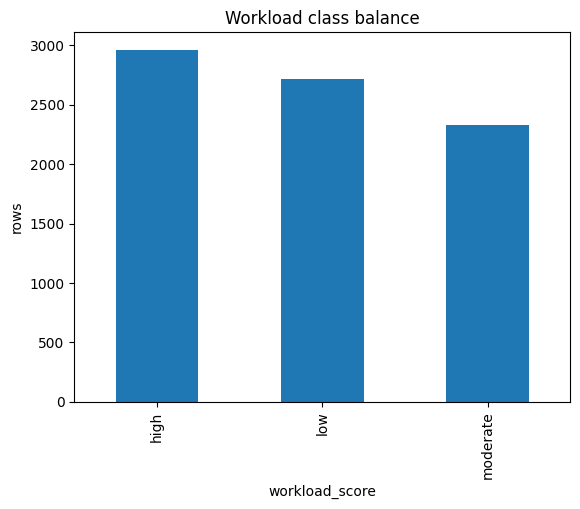

In [8]:
y.value_counts().plot(kind='bar', title='Workload class balance')
plt.ylabel('rows')
plt.show()

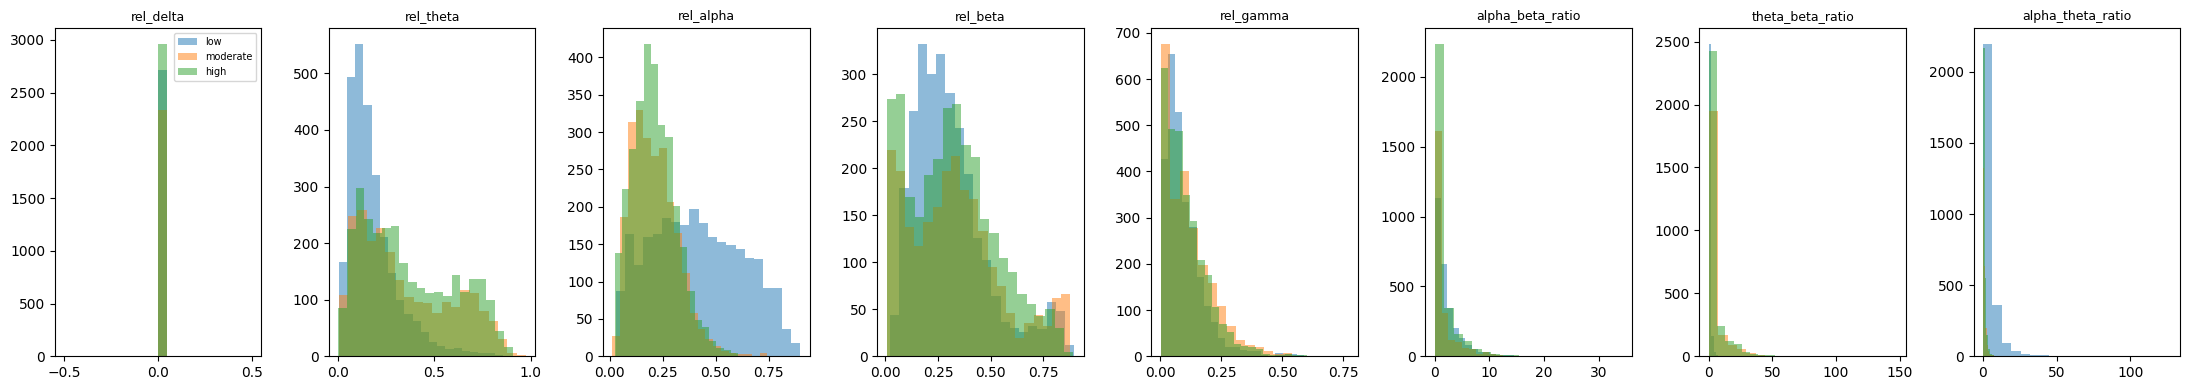

In [9]:
fig, axes = plt.subplots(1, len(FEATURE_NAMES), figsize=(22, 4))
for ax, feat in zip(axes, FEATURE_NAMES):
    for label in y.unique():
        ax.hist(X.loc[y == label, feat], bins=20, alpha=0.5, label=label)
    ax.set_title(feat, fontsize=9)
axes[0].legend(fontsize=7)
plt.tight_layout()
plt.show()

## 4. Subject-independent cross-validation: LR baseline vs Random Forest

See `train.py` for the full script version (also does the final held-out-subject evaluation, confusion matrix, and saves the deployed model). This section is for interactive exploration/tuning.

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

lr = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000))])
rf = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42, class_weight='balanced')

gkf = GroupKFold(n_splits=5)
for name, model in [('Logistic Regression', lr), ('Random Forest', rf)]:
    scores = cross_val_score(model, X, y, cv=gkf, groups=student_groups, scoring='f1_macro')
    print(f'{name:22s} mean macro-F1: {scores.mean():.3f}  (per fold: {np.round(scores, 3)})')

Logistic Regression    mean macro-F1: 0.460  (per fold: [0.365 0.53  0.453 0.49  0.462])


Random Forest          mean macro-F1: 0.486  (per fold: [0.383 0.504 0.481 0.535 0.525])


## 5. Next: run `train.py` for the final held-out-subject evaluation + saved model

```bash
python train.py
```
Saves `models/workload_classifier.joblib` + `models/metadata.json`, which `app/streamlit_app.py` loads directly at its prediction hook point.